Exploratory data analysis for the data to observe patterns and trends in the data

In [ ]:
import pandas as pd 
import numpy as np 
import seaborn as sns
#load dataset
df = pd.read_csv("../data/creditcard.csv")

In [6]:
pd.set_option("display.max_columns",None)
print(df.head())
df.info()


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10       V11       V12       V13       V14  \
0  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169   
1  0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095 -0.143772   
2  0.247676 -1.514654  0.207643  0.624501  0.066084  0.717293 -0.165946   
3  0.377436 -1.387024 -0.054952 -0.226487  0.178228  0.507757 -0.287924   
4 -0.270533  0.817739  0.753074 -0.822843  0.538196  1.345852 -1.119670   

        V15       V16       V17       V18       V19       V20 

### Initial Observations
- The dataset contains 284,807 transactions with no missing values.
- All features are numeric due to prior anonymization.
- The target variable `Class` is binary (0: normal, 1: fraud).
- No categorical encoding or missing value imputation is required.

In [10]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [11]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

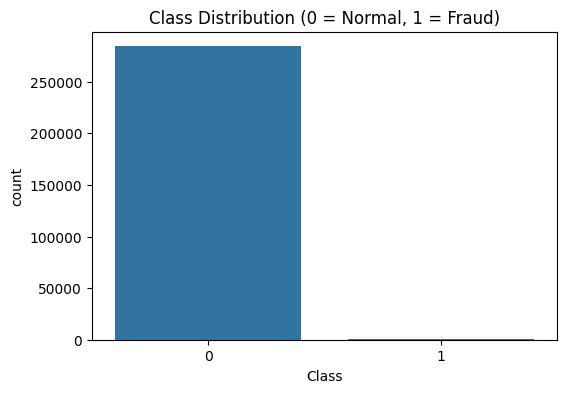

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()


### Class Imbalance Observation

The dataset is extremely imbalanced, with fraudulent transactions making up only ~0.17% of the data.
As a result, accuracy is not a reliable evaluation metric for this problem.

Instead, the model evaluation will focus on:
- Recall (to minimize missed fraud cases)
- Precision (to control false alarms)
- F1-score
- Precision-Recall AUC (PR-AUC)